# SWMAL Exercise

## Learning Curves

### The Generalization Error, Over- and Underfitting, Early Stopping, and Optimal Capacity

<img src="https://itundervisning.ase.au.dk/SWMAL/L07-Generalisation/Figs/dl_generalization_error.png" alt="WARNING: could not get image from server." style="height:500px">


### Qa) The Generalization Error

Fig. 5.3 illustrates the fundamental relationship between a model's capacity (its complexity) and its ability to minimize error on both known and unknown data.

X-axis (Capacity): This represents the model's ability to fit a wide variety of functions. Low capacity means a simple model (like a straight line), while high capacity means a complex model.

Y-axis (Error): This represents the difference between the model’s predictions and the true values.

Underfitting Zone: 
Located on the left side of the graph where capacity is low. Here, both training error and generalization error are high. The model is too simple to capture the underlying structure of the data (e.g., trying to fit a curved relationship with a straight line).

Overfitting Zone:
Located on the right side of the graph where capacity is high. While the training error continues to drop, the generalization error begins to rise. The model has started to "memorize" the noise and specific fluctuations in the training set rather than learning the general pattern.

Generalization Gap:
This is the vertical distance between the training error and the generalization error. As capacity increases, this gap consistently widens. A large gap is a primary symptom of overfitting, indicating that the model's success on training data is not translating to real-world performance.

Optimal Capacity:
Marked by the red vertical line, this is the "sweet spot." It occurs at the point where the generalization error is at its absolute minimum. At this level of capacity, the model is complex enough to learn the underlying patterns (minimizing underfitting) but simple enough to ignore the noise (minimizing overfitting).

### Qb Learning Curves

Adding the ability to remember the previous MSE.

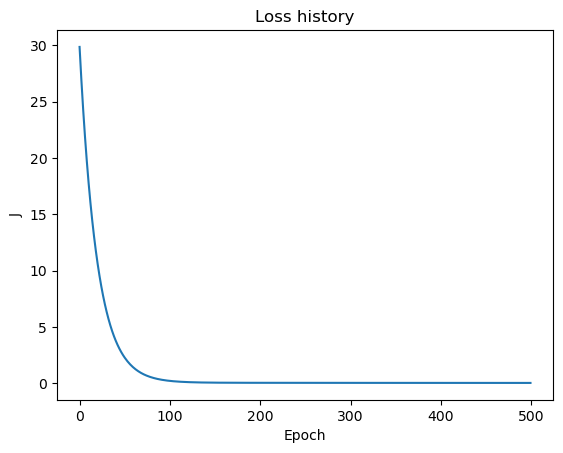

OK


In [ ]:

# Had some problems with importing MyLinReg, so i am just calling it from the bottom of the notebook.

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Create Data
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 4 + np.random.randn(100) * 0.1

r = MyLinReg(eta0=0.01, max_iter=500) 
r.fit(X, y)

%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(r.history_)

ax.set_title("Loss history")
ax.set_xlabel("Epoch")
ax.set_ylabel("J")

zoom_axis = False
if zoom_axis:
    limits_x = ax.get_xlim()
    limits_y = ax.get_ylim()
    ax.set_ylim([0, limits_y[1]/10]) # zoom on y axis
    
plt.show()

print("OK")

### Qc)  Early Stopping

Early stopping is used to prevent overfitting. During training, a model's error on the training set will almost always decrease. However, its error on a separate validation set follows a decreasing curve, it decreases while the model is learning the general patterns, but eventually begins to rise once the model starts "memorizing" the noise or specific details of the training data.

The "Early Stopping" algorithm monitors this validation error and halts training as soon as the error stops improving, for a predefined number of epochs (patience).

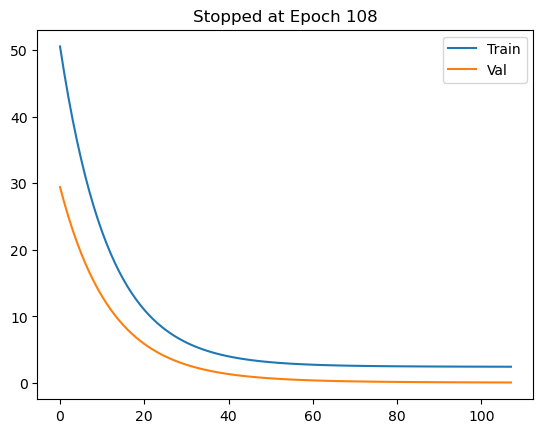

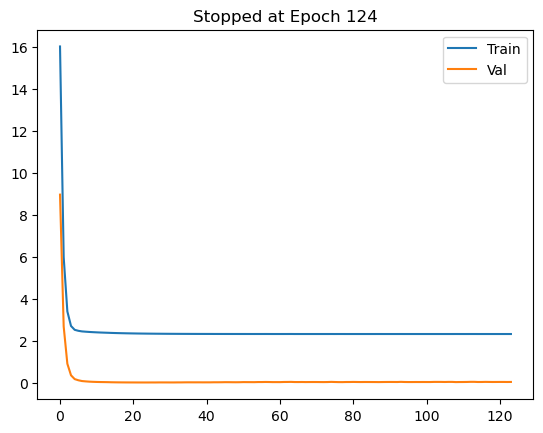

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create Data
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 4 + np.random.randn(100) * 0.1
X_val = np.random.rand(20, 1)
y_val = 3 * X_val.squeeze() + 4 + np.random.randn(20) * 0.1

# Train Batch (Stops quickly because it's smooth)
model_batch = MyLinReg(max_iter=1000, eta0=0.01, tol=1e-2, n_iter_no_change=5)
model_batch.fit(X_train, y_train, X_val, y_val, method='batch')

# Train SGD
model_sgd = MyLinReg(max_iter=1000, eta0=0.001, tol=1e-6, n_iter_no_change=100) # Increased patience, but higher tol
model_sgd.fit(X_train, y_train, X_val, y_val, method='sgd')

# 3. Plot
plt.plot(model_batch.history_, label='Train')
plt.plot(model_batch.val_history_, label='Val')
plt.title(f"Stopped at Epoch {len(model_batch.history_)}")
plt.legend()
plt.show()


# 3. Plot
plt.plot(model_sgd.history_, label='Train')
plt.plot(model_sgd.val_history_, label='Val')
plt.title(f"Stopped at Epoch {len(model_sgd.history_)}")
plt.legend()
plt.show()

### Qe Conclusion

Observations from the early stopping:
Batch GD is a steady, Because the descent path is smooth, the error decreases consistently. It only stops when the curve is mathematically flat.

SGD has a noisy path. Without high patience, it would stop at the first random "bounce" in error. The high patience (100) allows it to ignore short-term noise and stop only when the long-term trend stops improving.

To really se early stopping in action in action, it would be interesting to fit a polynomial, but that would be a task for another day.

In [34]:
import numpy as np

class MyLinReg():
    def __init__(self, eta0=0.03, max_iter=500, tol=1, n_iter_no_change=5, verbose=False):
        self.eta0 = eta0
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change
        self.verbose = verbose
        self.coef_ = None
        self.history_ = []      
        self.val_history_ = []  

    def _add_bias(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y, X_val=None, y_val=None, method='batch'):
        X_b = self._add_bias(X)
        n_samples, n_features = X_b.shape
        self.coef_ = np.zeros(n_features)
        self.best_coef_ = None 
        
        self.history_, self.val_history_ = [], []
        best_val_loss = float('inf')
        no_improvement_count = 0

        for epoch in range(self.max_iter):
            # Optimization
            if method == 'batch':
                gradients = (2/n_samples) * X_b.T @ (X_b @ self.coef_ - y)
                self.coef_ -= self.eta0 * gradients
            elif method == 'sgd':
                indices = np.random.permutation(n_samples)
                for i in indices:
                    xi, yi = X_b[i:i+1], y[i:i+1]
                    gradients = 2 * xi.T @ (xi @ self.coef_ - yi)
                    self.coef_ -= self.eta0 * gradients

            # save history
            train_loss = self.mse(X, y)
            self.history_.append(train_loss)
            
            if X_val is not None:
                val_loss = self.mse(X_val, y_val)
                self.val_history_.append(val_loss)

                # Check for improvement
                if val_loss < best_val_loss - self.tol:
                    best_val_loss = val_loss
                    self.best_coef_ = self.coef_.copy() 
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1

                if no_improvement_count >= self.n_iter_no_change:
                    # Roll back to best weights found
                    self.coef_ = self.best_coef_
                    if self.verbose: print(f"Early stop at {epoch}")
                    break

    def predict(self, X):
        X_b = self._add_bias(X)
        return X_b @ self.coef_

    def mse(self, X, y_true):
        return np.mean((self.predict(X) - y_true)**2)